In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from src.config import RAW_DATA_DIR

## 1. Load Raw Data

We load the CSV created by the batch scraper.  
This file contains the raw price history for all selected players.

In [4]:
df = pd.read_csv(RAW_DATA_DIR/"fut_prices_raw.csv")
df.head()

,player_id,player_name,date,price
0,254,lionel-messi,2025-09-18,33512
1,254,lionel-messi,2025-09-19,31182
2,254,lionel-messi,2025-09-20,23920
3,254,lionel-messi,2025-09-21,29705
4,254,lionel-messi,2025-09-22,35307


## 2. Basic Dataset Overview

We check:
- number of rows  
- number of unique players  
- date range  
- missing values  
- data types  


In [3]:
print("Rows:", len(df))
print("Players:", df["player_name"].nunique())
print("Date range:", df["date"].min(), "to", df["date"].max())

df.info()
df.isna().sum()

Rows: 6507
Players: 49
Date range: 2025-09-18 to 2026-03-08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6507 entries, 0 to 6506
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   player_id    6507 non-null   int64 
 1   player_name  6507 non-null   object
 2   date         6507 non-null   object
 3   price        6507 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 203.5+ KB


player_id      0
player_name    0
date           0
price          0
dtype: int64

## 3. Convert Date Column

We convert the `date` column to datetime for proper time‑series handling.

In [4]:
df["date"] = pd.to_datetime(df["date"])
df.sort_values(["player_name", "date"], inplace=True)

## 4. Price Distribution

FUT prices vary massively between:
- cheap basic cards (gold)
- meta cards (players used by majority of playere because they are really good)  
- icons  
- promos (special card of players) 

Let’s visualize the overall distribution.

Text(0, 0.5, 'Count')

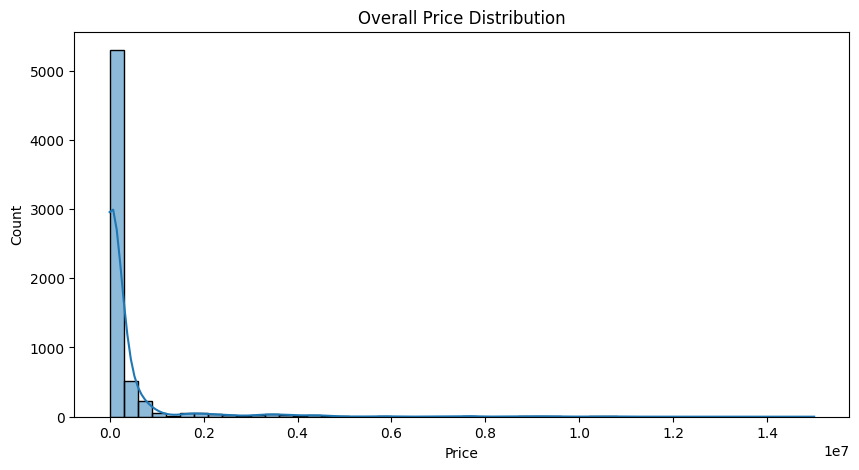

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Overall Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

## 5. Price History for a Sample Player

Let’s pick a player and visualize their price evolution over time.

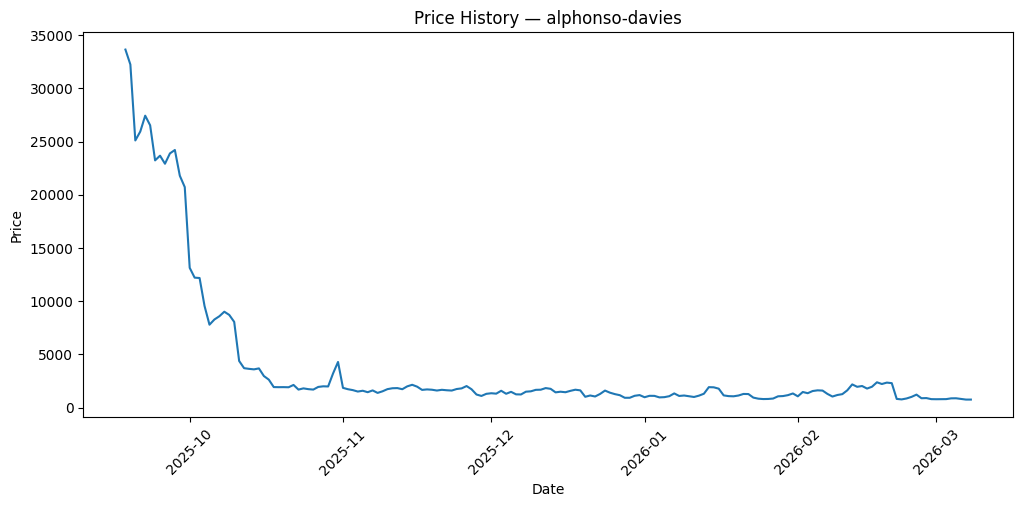

In [6]:
sample_player = df["player_name"].unique()[0]
sample_df = df[df["player_name"] == sample_player]

plt.figure(figsize=(12,5))
plt.plot(sample_df["date"], sample_df["price"])
plt.title(f"Price History — {sample_player}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

## 6. Compare Price Trends Across Players

Let’s visualize a few players together to see how their price curves differ.

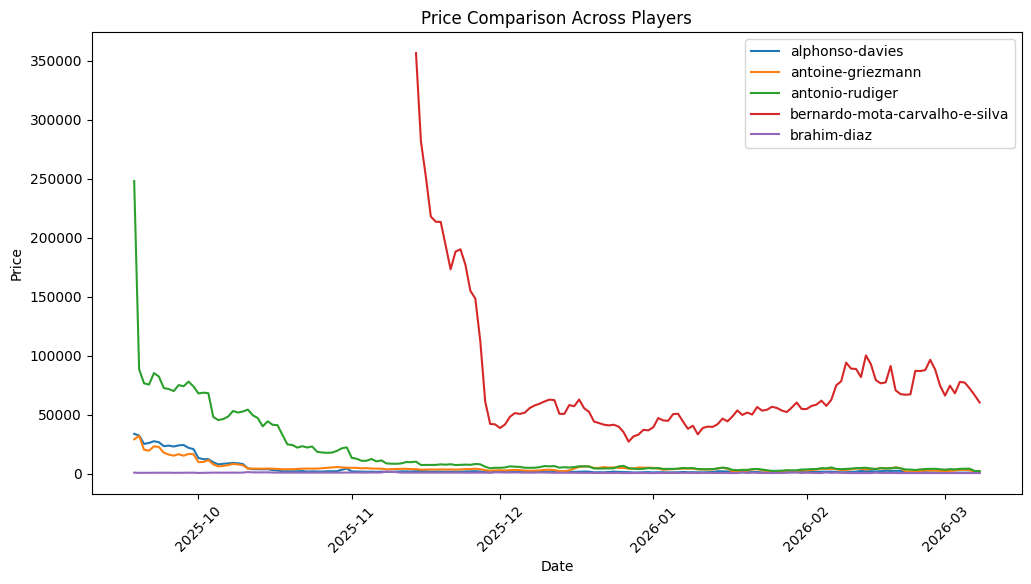

In [7]:
players_to_plot = df["player_name"].unique()[:5]

plt.figure(figsize=(12,6))

for p in players_to_plot:
    temp = df[df["player_name"] == p]
    plt.plot(temp["date"], temp["price"], label=p)

plt.title("Price Comparison Across Players")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [10]:
import plotly.express as px
players_to_plot = df[df["player_name"].isin(df["player_name"].unique()[:11])]
px.line(players_to_plot, x="date", y="price", color="player_name", title="Price Comparison Across Players")

## 7. Weekly Patterns

FUT markets often show:
- Thursday rises (rewards)
- Weekend dips (WL sell-off)
- Monday/Tuesday stabilization

Let’s check average price by day of week.

In [ ]:
import plotly.express as px

df["day_of_week"] = df["date"].dt.weekday
avg_by_day = df.groupby("day_of_week")["price"].mean().reset_index()

fig = px.line(avg_by_day, x="day_of_week", y="price", title="Average Price by Day of Week")
fig.update_xaxes(title_text="Day of Week (0=Mon, 6=Sun)")
fig.update_yaxes(title_text="Average Price")
fig.show()

## 8. Volatility Analysis

Some players have stable prices.  
Others fluctuate heavily due to:
- promos  
- SBC demand  
- pack supply  
- meta shifts  

Let’s compute simple volatility using percentage change.

In [15]:
df_sorted = df.sort_values(["player_name", "date"])
df_sorted["pct_change"] = df_sorted.groupby("player_name")["price"].pct_change()

volatility = df_sorted.groupby("player_name")["pct_change"].std().sort_values(ascending=False)
volatility.head(10)

player_name
brahim-diaz                            0.255527
willian-pacho                          0.245456
marcos-llorente-moreno                 0.222572
eduardo-camavinga                      0.166435
alphonso-davies                        0.163463
nuno-alexandre-tavares-mendes          0.158974
ronald-araujo                          0.158121
antoine-griezmann                      0.155833
federico-dimarco                       0.149899
cristiano-ronaldo-dos-santos-aveiro    0.142111
Name: pct_change, dtype: float64

### Visualizing Volatility for Top 5 Most Volatile Players

In [17]:
top_volatile = volatility.head(5).index
top_volatile_players_to_plot = df[df["player_name"].isin(top_volatile)]
fig = px.line(top_volatile_players_to_plot, x="date", y="price", color="player_name",title="Most Volatile Players — Price Curves")
fig.update_xaxes(title_text="Date", tickangle=45)
fig.update_yaxes(title_text="Price")
fig.show()

# 9. Conclusions

From this EDA, we learned:

### 1. Price levels vary massively across players  
Gold → promo → icons → meta all behave differently.

### 2. Weekly patterns exist  
Prices often dip on weekends and rise on Thursdays.

### 3. Volatility differs by player  
Meta cards and SBC‑linked cards show more movement.

### 4. Data quality is good  
No major missing values or scraping issues.

---

Next step: **02_features.ipynb — Feature Engineering**